# 3주차: Random split은 GNN을 과대평가하는가?

2주차까지 우리는 random split 하나로만 모델을 평가했습니다. 그런데 molecule에서는 이게 위험합니다.
Training set에 benzene · toluene · phenol이 들어 있고 test set에도 비슷한 aromatic structure가 들어가면,
GNN은 **거의 같은 chemical structure를 이미 본 상태**에서 평가받게 됩니다.

그래서 molecular ML에서는 **scaffold split**을 씁니다. RDKit의 Murcko scaffold로 각 분자의 2D
structural framework를 뽑고, 서로 다른 framework가 train과 test에 나뉘도록 자릅니다. OGB와
MoleculeNet도 같은 이유로 이 방식을 씁니다.

이번 주의 핵심 실험은 **완전히 같은 모델을 두 번 평가**하는 것입니다.

| | Experiment A | Experiment B |
|---|---|---|
| Split | Random | Murcko scaffold |
| 관계 | train molecules ≈ test molecules | train scaffolds ∩ test scaffolds = ∅ |

그리고 묻습니다. **GNN이 물리적인 solubility relationship을 배운 것인가, 아니면 training set과
비슷한 molecular motif를 memorization한 것인가?**

> **미리 짚고 갈 함정 하나.** Scaffold split은 성능만 떨어뜨리는 게 아니라 **target 분포 자체를 옮깁니다.**
> 그래서 완벽한 모델이라도 RMSE가 오릅니다. 이번 노트북은 `Dummy (mean)` baseline을 통제군으로 남겨
> "분포가 이동해서 생긴 손해"와 "표현이 전이되지 않아서 생긴 손해"를 분리합니다.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from rdkit import Chem
from rdkit.Chem import Draw

from ai4sci_molecule.week1 import load_esol, make_random_split
from ai4sci_molecule.week2 import resolve_device
from ai4sci_molecule.week3 import (
    ACYCLIC_SCAFFOLD, SweepConfig, aggregate_metrics, bin_similarity_errors,
    generalization_gap, load_or_run_sweep, make_scaffold_split, murcko_scaffold,
    nearest_neighbour_similarity, plot_generalization_gap, plot_scaffold_distribution,
    plot_similarity_distribution, plot_similarity_error, plot_split_comparison,
    save_figures, scaffold_statistics, scaffold_table, similarity_error_correlation,
    split_scaffold_overlap, target_shift_table,
)

RESULTS_DIRECTORY = Path("..") / "results" / "week3"
DEVICE = resolve_device("auto")
CONFIG = SweepConfig()
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["font.family"] = "UnDotum"
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.max_columns", 30)
print(f"device: {DEVICE}, seeds: {CONFIG.seeds}, splits: {CONFIG.split_types}")

device: cuda, seeds: (0, 1, 2, 3, 4), splits: ('random', 'scaffold', 'scaffold_shuffled')


## 1. Murcko scaffold란 무엇인가

Murcko scaffold는 분자에서 **side chain을 떼어내고 ring system과 그것을 잇는 linker만 남긴** 골격입니다.
benzene · toluene · phenol · aniline은 치환기만 다르므로 모두 같은 scaffold `c1ccccc1`로 축약됩니다.
naphthalene은 ring system이 다르므로 별도 scaffold가 되고, ethanol처럼 ring이 없는 분자는
scaffold가 **빈 문자열**이 됩니다. 이 마지막 경우가 뒤에서 중요한 설계 결정을 만듭니다.

,name,smiles,murcko_scaffold
0,benzene,c1ccccc1,c1ccccc1
1,toluene,Cc1ccccc1,c1ccccc1
2,phenol,Oc1ccccc1,c1ccccc1
3,naphthalene,c1ccc2ccccc2c1,c1ccc2ccccc2c1
4,ethanol,CCO,(없음 - acyclic)


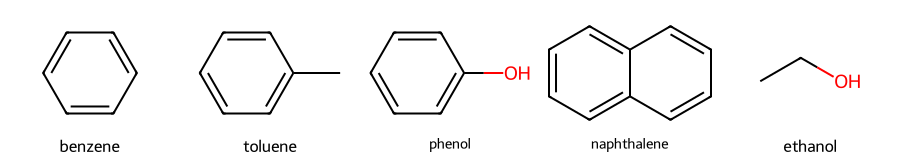

In [2]:
examples = ["c1ccccc1", "Cc1ccccc1", "Oc1ccccc1", "c1ccc2ccccc2c1", "CCO"]
names = ["benzene", "toluene", "phenol", "naphthalene", "ethanol"]
example_table = pd.DataFrame({
    "name": names,
    "smiles": examples,
    "murcko_scaffold": [murcko_scaffold(s) or "(없음 - acyclic)" for s in examples],
})
display(example_table)
Draw.MolsToGridImage(
    [Chem.MolFromSmiles(s) for s in examples],
    legends=names, molsPerRow=5, subImgSize=(180, 160),
)

## 2. ESOL은 생각보다 훨씬 좁다

1,128개 분자가 있다고 해서 1,128개의 서로 다른 골격이 있는 게 아닙니다. 실제로 세어 보면
scaffold는 몇 백 개뿐이고, 그중 소수가 데이터셋의 절반을 차지합니다. 이 편중이 바로
random split이 낙관적으로 보이는 이유입니다.

In [3]:
dataset = load_esol(Path("..") / "data" / "MoleculeNet")
smiles = [graph.smiles for graph in dataset]
targets = np.array([float(graph.y.item()) for graph in dataset])

statistics = scaffold_statistics(smiles)
display(pd.Series(statistics, name="value").to_frame())

table = scaffold_table(smiles)
top = table.head(10).copy()
top["scaffold"] = top["scaffold"].replace({ACYCLIC_SCAFFOLD: "(acyclic)"})
display(top)
print(
    f"상위 2개 그룹이 전체의 "
    f"{table['fraction'].head(2).sum():.1%}를 차지합니다."
)

,value
num_molecules,1128.000000
num_scaffolds,269.000000
molecules_per_scaffold_mean,4.193309
median_scaffold_size,1.000000
largest_scaffold_size,317.000000
largest_scaffold_fraction,0.281028
singleton_scaffold_count,194.000000
singleton_scaffold_fraction,0.721190
singleton_molecule_fraction,0.171986
acyclic_molecule_count,317.000000


,scaffold,molecules,fraction
0,(acyclic),317,0.281028
1,c1ccccc1,254,0.225177
2,c1ccc(-c2ccccc2)cc1,39,0.034574
3,c1ccc2ccccc2c1,22,0.019504
4,O=C1CC(=O)NC(=O)N1,21,0.018617
5,O=C1C=C2CCC3C4CCCC4CCC3C2CC1,17,0.015071
6,c1ncncn1,16,0.014184
7,c1ccncc1,14,0.012411
8,c1ccc(Cc2ccccc2)cc1,12,0.010638
9,C1CCCCC1,10,0.008865


상위 2개 그룹이 전체의 50.6%를 차지합니다.


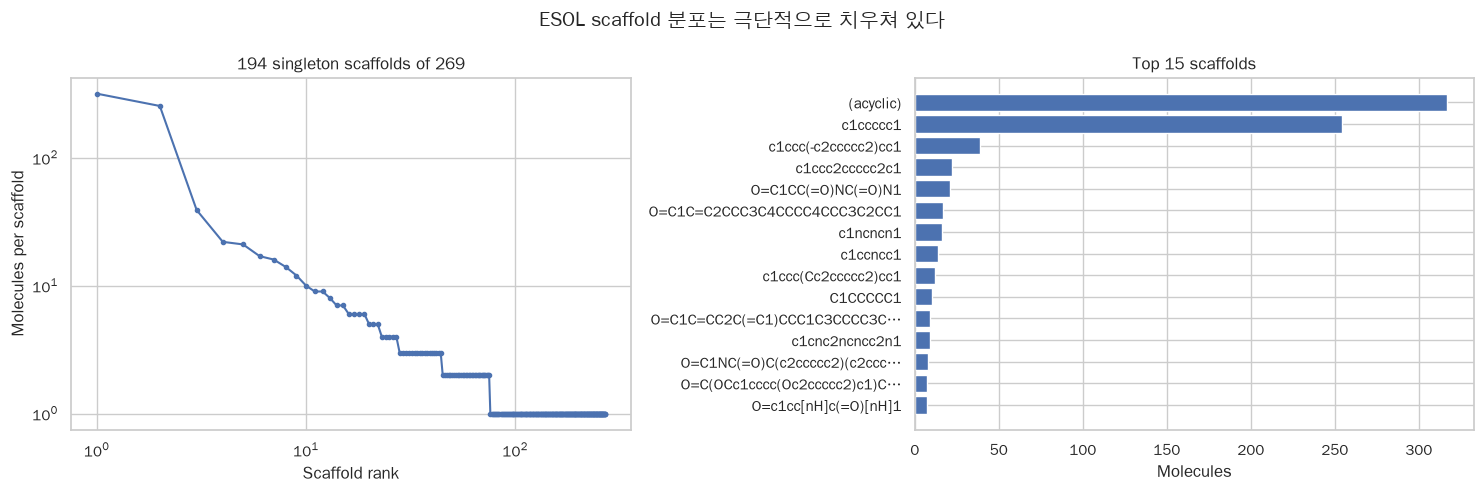

In [4]:
figure_scaffold = plot_scaffold_distribution(smiles, title="ESOL scaffold 분포는 극단적으로 치우쳐 있다")
plt.show()

## 3. Ring이 없는 분자를 어떻게 다룰 것인가

ESOL의 28%는 alkane · alcohol · haloalkane처럼 **ring이 아예 없는 분자**입니다. 이들의 Murcko
scaffold는 전부 빈 문자열이라 두 가지 처리가 가능합니다.

- `acyclic_policy="group"` — 빈 scaffold를 **하나의 거대한 그룹**으로 봅니다. 가장 큰 그룹이므로
  통째로 train에 들어가고, 결과적으로 **test set에는 acyclic 분자가 한 개도 남지 않습니다.**
  DeepChem · MoleculeNet · OGB의 관례이고, 이번 주의 기본값입니다.
- `acyclic_policy="unique"` — acyclic 분자마다 고유 scaffold를 부여해 세 subset에 흩뿌립니다.
  split이 눈에 띄게 쉬워집니다.

기본값을 `"group"`으로 두되, **그 대가를 숨기지 않는 것**이 중요합니다. 아래 표가 그 대가를 보여줍니다.

In [5]:
policy_rows = []
for policy in ("group", "unique"):
    policy_split = make_scaffold_split(smiles, acyclic_policy=policy)
    test_indices = policy_split["test"]
    policy_rows.append({
        "acyclic_policy": policy,
        "scaffold 그룹 수": int(scaffold_statistics(smiles, acyclic_policy=policy)["num_scaffolds"]),
        "test 분자 수": len(test_indices),
        "test 내 acyclic 분자": sum(murcko_scaffold(smiles[int(i)]) == ACYCLIC_SCAFFOLD for i in test_indices),
        "test logS 평균": float(targets[test_indices].mean()),
    })
display(pd.DataFrame(policy_rows))

,acyclic_policy,scaffold 그룹 수,test 분자 수,test 내 acyclic 분자,test logS 평균
0,group,269,113,0,-3.551761
1,unique,585,113,48,-3.127204


## 4. 두 split은 정말 다른 과제인가

주장을 하기 전에 **split이 실제로 의도한 대로 잘렸는지** 확인해야 합니다. 두 가지를 봅니다.

1. `split_scaffold_overlap` — test 분자 중 train과 같은 scaffold를 가진 비율.
2. Nearest-neighbour Tanimoto similarity — 각 test 분자가 train의 **가장 비슷한 분자**와 얼마나 닮았는지
   (Morgan fingerprint, radius 2).

In [6]:
splits = {
    "random": make_random_split(len(dataset), seed=0),
    "scaffold": make_scaffold_split(smiles),
}
for name, split in splits.items():
    print(f"[{name}] " + str({key: len(value) for key, value in split.items()}))
    display(split_scaffold_overlap(smiles, split))

[random] {'train': 902, 'validation': 113, 'test': 113}


,subset,molecules,scaffolds,scaffolds_shared_with_train,molecules_with_train_scaffold,shared_molecule_fraction
0,train,902,234,234,902,1.000000
1,validation,113,46,24,90,0.796460
2,test,113,39,26,100,0.884956


[scaffold] {'train': 902, 'validation': 113, 'test': 113}


,subset,molecules,scaffolds,scaffolds_shared_with_train,molecules_with_train_scaffold,shared_molecule_fraction
0,train,902,103,103,902,1.0
1,validation,113,83,0,0,0.0
2,test,113,83,0,0,0.0


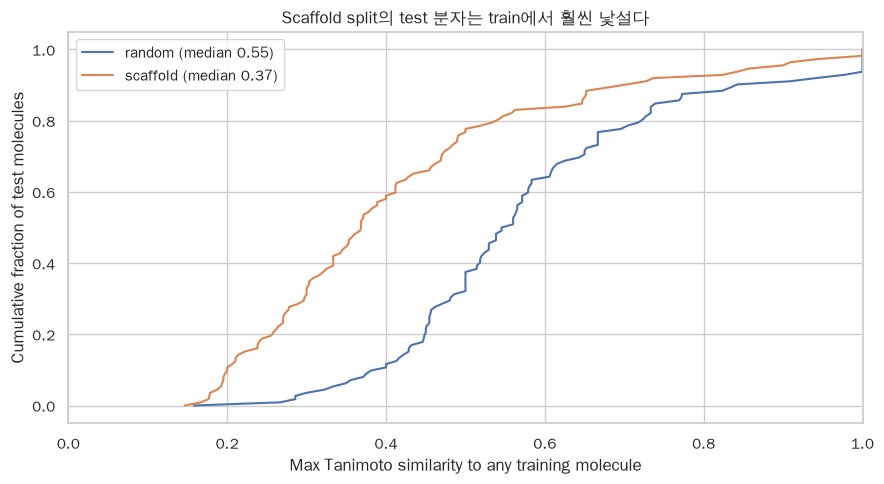

In [7]:
similarity_frame = pd.concat(
    [
        pd.DataFrame({
            "split_type": name,
            "seed": 0,
            "dataset_index": split["test"],
            "nearest_train_similarity": nearest_neighbour_similarity(
                [smiles[int(i)] for i in split["test"]],
                [smiles[int(i)] for i in split["train"]],
            ),
        })
        for name, split in splits.items()
    ],
    ignore_index=True,
)
figure_similarity = plot_similarity_distribution(
    similarity_frame, title="Scaffold split의 test 분자는 train에서 훨씬 낯설다"
)
plt.show()

그리고 **target 분포가 어떻게 이동했는지**를 반드시 같이 봐야 합니다. scaffold split은 난이도만
올리는 게 아니라 test set의 logS 평균 자체를 바꿉니다. 이 이동분은 어떤 모델이든 똑같이 손해를 보는 부분입니다.

In [8]:
display(target_shift_table(targets, splits))

,split_type,subset,molecules,target_mean,target_std
0,random,train,902,-3.052277,2.066281
1,random,validation,113,-2.984363,2.230228
2,random,test,113,-3.098478,2.184670
3,scaffold,train,902,-2.922614,2.076647
4,scaffold,validation,113,-3.566088,2.167404
5,scaffold,test,113,-3.551761,2.016263


## 5. 같은 모델, 두 regime, 5개 seed

이제 1주차 descriptor baseline 3종(`Dummy (mean)` · `Linear` · `MLP`)과 2주차 GNN 2종(`GCN` · `GIN`)을
**hyperparameter를 하나도 바꾸지 않고** 각 split regime에서 seed 5개로 학습합니다.

seed가 무엇을 재는지는 regime마다 다릅니다. 이 차이를 인식하지 않으면 error bar를 잘못 읽게 됩니다.

- `random` — seed가 split과 학습을 **둘 다** 바꿉니다. std = split noise + training noise.
- `scaffold` — split이 결정적이라 seed는 학습만 바꿉니다. std = **training noise만.**
- `scaffold_shuffled` — scaffold 제약을 지키면서 split을 매번 다시 뽑는 부록. std가 **split 자체의 변동폭**입니다.

전체 sweep은 GPU에서 약 10분 걸립니다. `load_or_run_sweep`은 `results/week3/`에 결과가 있고 설정이
같으면 그대로 불러오므로, 두 번째 실행부터는 즉시 끝납니다.

In [9]:
sweep = load_or_run_sweep(dataset, directory=RESULTS_DIRECTORY, config=CONFIG, device=DEVICE)
print(f"metrics rows: {len(sweep.metrics)}, prediction rows: {len(sweep.predictions):,}")
summary = aggregate_metrics(sweep.metrics)
display(
    summary[["split_type", "model", "representation", "RMSE_mean", "RMSE_std", "MAE_mean", "R2_mean"]]
    .round(3)
)

metrics rows: 150, prediction rows: 8,410


,split_type,model,representation,RMSE_mean,RMSE_std,MAE_mean,R2_mean
0,random,Dummy (mean),RDKit descriptors,2.155,0.142,1.723,-0.007
1,scaffold,Dummy (mean),RDKit descriptors,2.112,0.000,1.646,-0.097
2,scaffold_shuffled,Dummy (mean),RDKit descriptors,2.275,0.575,1.771,-0.445
3,random,Linear,RDKit descriptors,0.998,0.017,0.772,0.782
4,scaffold,Linear,RDKit descriptors,1.345,0.000,0.997,0.555
5,scaffold_shuffled,Linear,RDKit descriptors,1.139,0.088,0.875,0.605
6,random,MLP,RDKit descriptors,0.756,0.068,0.608,0.872
7,scaffold,MLP,RDKit descriptors,0.947,0.017,0.745,0.779
8,scaffold_shuffled,MLP,RDKit descriptors,0.968,0.066,0.732,0.707
9,random,GCN,Molecular graph,0.914,0.411,0.594,0.799


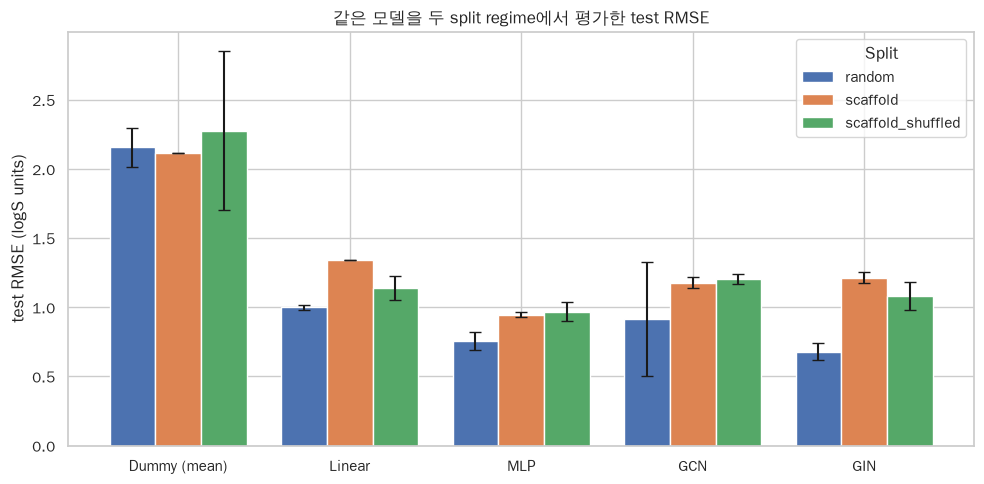

In [10]:
figure_comparison = plot_split_comparison(
    sweep.metrics, title="같은 모델을 두 split regime에서 평가한 test RMSE"
)
plt.show()

## 6. Generalization gap을 어떻게 읽을 것인가

`gap = scaffold RMSE − random RMSE`입니다. 하지만 **gap이 크다고 곧바로 memorization은 아닙니다.**
앞에서 본 것처럼 scaffold split은 test target 분포를 옮기기 때문입니다.

그래서 `Dummy (mean)`의 gap이 기준선입니다. Dummy는 train 평균만 예측하므로, 그 gap은 **오로지 분포
이동 때문에 생긴 손해**입니다. 어떤 모델의 gap이 Dummy의 gap을 넘어서는 만큼이 그 모델의
**표현이 새로운 골격으로 전이되지 않은 몫**입니다.

`gap_over_pooled_std`는 gap을 seed 표준편차로 나눈 **기술적인 effect size**입니다. seed가 5개이고
두 regime의 test set이 서로 다르며 scaffold split이 결정적이므로, 표준적인 유의성 검정은 여기 적용되지
않습니다. 크기의 눈금으로만 읽으세요. (Dummy와 Linear처럼 결정적인 모델은 scaffold regime에서 std가
정확히 0이 되어 이 값이 발산합니다.)

,model,representation,random_mean,random_std,scaffold_mean,scaffold_std,gap,gap_ratio,gap_over_pooled_std
0,Dummy (mean),RDKit descriptors,2.155,0.142,2.112,0.000,-0.043,0.980,-0.430
1,Linear,RDKit descriptors,0.998,0.017,1.345,0.000,0.347,1.347,28.613
2,MLP,RDKit descriptors,0.756,0.068,0.947,0.017,0.191,1.252,3.856
3,GCN,Molecular graph,0.914,0.411,1.177,0.041,0.263,1.288,0.900
4,GIN,Molecular graph,0.677,0.061,1.213,0.042,0.537,1.794,10.240


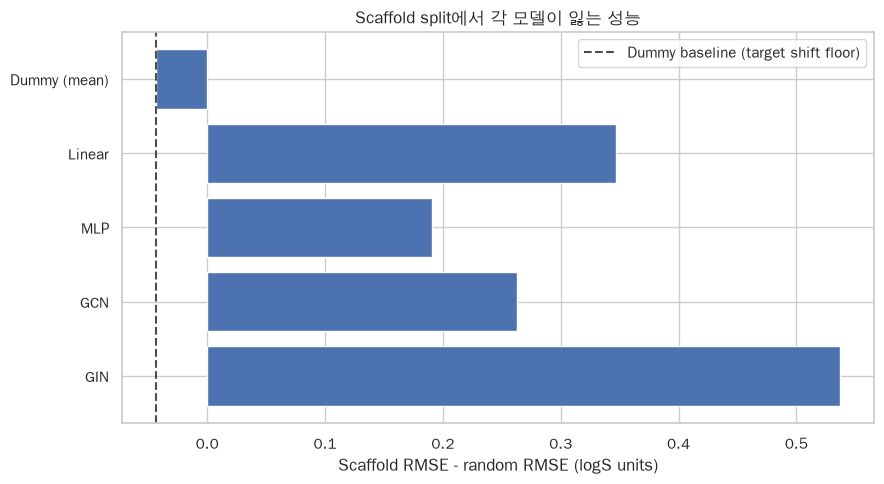

In [11]:
gaps = generalization_gap(sweep.metrics)
display(gaps.round(3))
figure_gap = plot_generalization_gap(sweep.metrics, title="Scaffold split에서 각 모델이 잃는 성능")
plt.show()

## 7. 오차 분해: 비슷한 걸 봤을 때만 잘 맞추는가

이것이 이번 주의 핵심 증거입니다. test 분자 하나하나에 대해 **train에서 가장 비슷한 분자와의 Tanimoto
similarity**를 계산해 두었으므로, similarity가 낮아질수록 오차가 커지는지 직접 볼 수 있습니다.

만약 모델이 물리적 관계를 배웠다면 similarity는 오차와 별 상관이 없어야 합니다.
반대로 similarity가 낮을수록 오차가 가파르게 커진다면, 그 모델은 **본 것과 비슷할 때만 잘하는** 것입니다.

In [12]:
correlations = similarity_error_correlation(sweep.predictions)
display(correlations.round(3))

,split_type,model,molecules,pearson,spearman,mean_similarity,mean_absolute_error
0,random,Dummy (mean),565,0.108,0.062,0.572,1.723
1,scaffold,Dummy (mean),565,0.295,0.273,0.416,1.646
2,scaffold_shuffled,Dummy (mean),552,0.218,0.229,0.446,1.768
3,random,Linear,565,0.084,0.031,0.572,0.772
4,scaffold,Linear,565,0.189,0.113,0.416,0.997
5,scaffold_shuffled,Linear,552,0.035,0.006,0.446,0.874
6,random,MLP,565,-0.040,-0.005,0.572,0.608
7,scaffold,MLP,565,-0.090,-0.090,0.416,0.745
8,scaffold_shuffled,MLP,552,-0.218,-0.215,0.446,0.732
9,random,GCN,565,-0.119,-0.083,0.572,0.594


In [13]:
binned = bin_similarity_errors(sweep.predictions)
display(
    binned.pivot_table(
        index=["split_type", "model"], columns="similarity_bin",
        values="mean_absolute_error", observed=True,
    ).round(3)
)

similarity_bin                  (-0.001, 0.2]  (0.2, 0.4]  (0.4, 0.6]  \
split_type        model                                                 
random            Dummy (mean)          1.673       1.578       1.638   
                  GCN                   3.178       0.645       0.531   
                  GIN                   0.997       0.586       0.500   
                  Linear                0.543       0.834       0.709   
                  MLP                   0.824       0.709       0.532   
scaffold          Dummy (mean)          1.325       1.370       1.868   
                  GCN                   1.075       1.111       0.677   
                  GIN                   1.232       1.081       0.592   
                  Linear                0.575       1.009       0.897   
                  MLP                   0.625       0.866       0.645   
scaffold_shuffled Dummy (mean)          1.317       1.322       2.024   
                  GCN                   1.026       1.068       0.926   
                  GIN                   1.084       0.965       0.786   
                  Linear                0.854       0.976       0.673   
                  MLP                   1.078       0.884       0.582   

similarity_bin                  (0.6, 0.8]  (0.8, 1.0]  
split_type        model                                 
random            Dummy (mean)       1.750       2.127  
                  GCN                0.533       0.597  
                  GIN                0.471       0.478  
                  Linear             0.709       1.021  
                  MLP                0.641       0.628  
scaffold          Dummy (mean)       2.007       2.700  
                  GCN                0.525       0.901  
                  GIN                0.682       0.883  
                  Linear             0.955       1.879  
                  MLP                0.490       0.780  
scaffold_shuffled Dummy (mean)       2.412       1.806  
                  GCN                0.842       0.788  
                  GIN                0.803       0.699  
                  Linear             1.100       1.320  
                  MLP                0.653       0.706

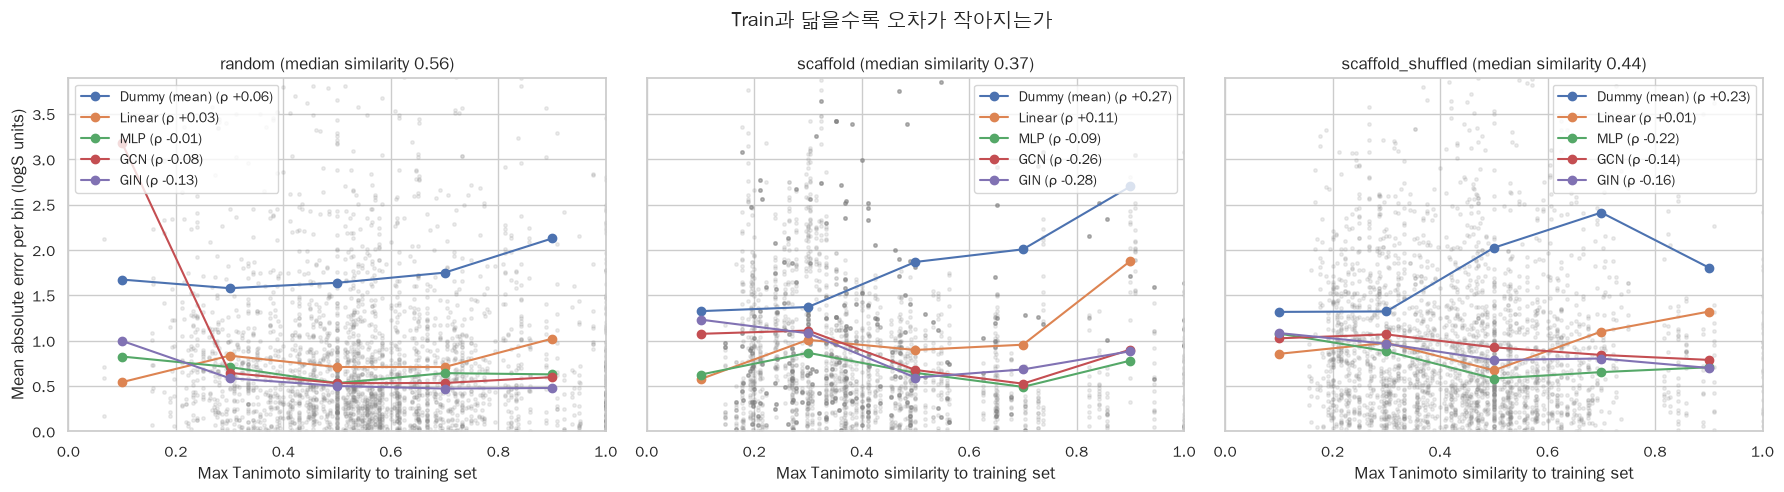

In [14]:
figure_error = plot_similarity_error(
    sweep.predictions, title="Train과 닮을수록 오차가 작아지는가"
)
plt.show()

## 8. 결과물 저장

모든 그림은 `results/week3/figures/`에 저장되고, 표와 원시 예측값은 같은 폴더의 CSV/JSON에 있습니다.
`uv run python -m ai4sci_molecule.week3`로 전부 재생성할 수 있습니다.

In [15]:
figures = {
    "scaffold_distribution": figure_scaffold,
    "similarity_distribution": figure_similarity,
    "split_comparison": figure_comparison,
    "generalization_gap": figure_gap,
    "similarity_error": figure_error,
}
for name, path in save_figures(figures, RESULTS_DIRECTORY / "figures").items():
    print(f"{name}: {path}")

scaffold_distribution: ../results/week3/figures/scaffold_distribution.png
similarity_distribution: ../results/week3/figures/similarity_distribution.png
split_comparison: ../results/week3/figures/split_comparison.png
generalization_gap: ../results/week3/figures/generalization_gap.png
similarity_error: ../results/week3/figures/similarity_error.png


## 9. 결론

아래 판정 출력이 이번 주의 요약입니다. 읽는 순서는 이렇습니다.

1. **gap** 자체는 얼마나 큰가.
2. **Dummy 대비 초과분** — 분포 이동을 제외하고 남는, 표현 전이 실패에 해당하는 몫.
3. **seed std** — 그 차이가 학습 noise보다 충분히 큰가.
4. **Spearman ρ** — scaffold regime에서 similarity가 낮을수록 오차가 커지는가.

한계도 같이 기억해야 합니다. deterministic scaffold split은 **단 하나의 실현**이고,
`acyclic_policy="group"` 때문에 test에는 acyclic 분자가 없으며, hyperparameter는 2주차의
random split에서 고른 값을 그대로 썼습니다(재조정하면 비교 자체가 무너지므로 의도적입니다).
자세한 해석과 한계는 `reports/week3.md`에 정리해 두었습니다.

In [16]:
dummy_gap = float(gaps.set_index("model").loc["Dummy (mean)", "gap"])
scaffold_rho = correlations[correlations["split_type"] == "scaffold"].set_index("model")["spearman"]

print(f"분포 이동만으로 생기는 gap (Dummy 기준선): {dummy_gap:+.3f} logS\n")
print(f"{'model':<14}{'random':>8}{'scaffold':>10}{'gap':>8}{'초과':>8}{'seed std':>10}{'ρ':>7}")
for row in gaps.itertuples():
    print(
        f"{row.model:<14}{row.random_mean:>8.3f}{row.scaffold_mean:>10.3f}"
        f"{row.gap:>+8.3f}{row.gap - dummy_gap:>+8.3f}{row.scaffold_std:>10.3f}"
        f"{scaffold_rho.get(row.model, float('nan')):>7.2f}"
    )

분포 이동만으로 생기는 gap (Dummy 기준선): -0.043 logS

model           random  scaffold     gap      초과  seed std      ρ
Dummy (mean)     2.155     2.112  -0.043  +0.000     0.000   0.27
Linear           0.998     1.345  +0.347  +0.390     0.000   0.11
MLP              0.756     0.947  +0.191  +0.234     0.017  -0.09
GCN              0.914     1.177  +0.263  +0.306     0.041  -0.26
GIN              0.677     1.213  +0.537  +0.580     0.042  -0.28
